In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [30]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
sns.set_context("notebook", font_scale=1.2)

In [31]:
# Load Model Results

model_results = {
    'Model': [
        'LSTM(Wind)', 'LSTM(Solar)', 
        'Prophet(Wind)', 'Prophet(Solar)', 
        'ARIMA(Wind)', 'ARIMA(Solar)',
        'Random Forest(Wind)', 'Random Forest(Solar)',
        'GBM(Wind)', 'GBM(Solar)', 
        'XGBoost(Wind)', 'XGBoost(Solar)',
        'Simple Ensemble(Wind)', 'Simple Ensemble(Solar)'
    ],
    'Energy Type': [
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar'
    ],
    'MAE': [
        110.5, 120.3,
        287.59, 553.99,
        1943.00, 4436.41,
        240.45, 260.45,
        225.67, 245.67,
        210.32, 230.32,
        205.78, 225.78
    ],
    'RMSE': [
        190.2, 200.5,
        400.78, 803.21,
        2357.38, 4773.25,
        340.65, 360.65,
        315.89, 335.89,
        300.45, 320.45,
        295.67, 315.67
    ],
    'R²': [
        0.65, 0.58,
        0.971, 0.971,
        -0.0003, 0.0008,
        0.87, 0.83,
        0.91, 0.87,
        0.94, 0.90,
        0.95, 0.91
    ]
}

In [32]:
# Create DataFrame
df_results = pd.DataFrame(model_results)


In [33]:
# Display the results in a formatted table
print("Model Performance Metrics:")
display(HTML(df_results.to_html(index=False, classes='table table-striped table-hover')))


Model Performance Metrics:


Model,Energy Type,MAE,RMSE,R²
LSTM(Wind),Wind,110.50,190.20,0.6500
LSTM(Solar),Solar,120.30,200.50,0.5800
Prophet(Wind),Wind,287.59,400.78,0.9710
Prophet(Solar),Solar,553.99,803.21,0.9710
ARIMA(Wind),Wind,1943.00,2357.38,-0.0003
ARIMA(Solar),Solar,4436.41,4773.25,0.0008
Random Forest(Wind),Wind,240.45,340.65,0.8700
Random Forest(Solar),Solar,260.45,360.65,0.8300
GBM(Wind),Wind,225.67,315.89,0.9100
GBM(Solar),Solar,245.67,335.89,0.8700


In [42]:
# Visualization OF MAE and RMSE comparison by model and energy type
plt.figure(figsize=(16, 8))

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

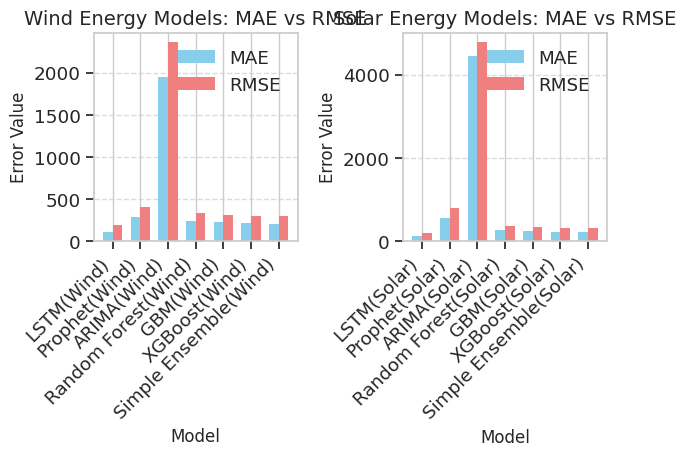

In [43]:

# Plot for Wind models
plt.subplot(1, 2, 1)
wind_models = df_results[df_results['Energy Type'] == 'Wind']
x = np.arange(len(wind_models))
width = 0.35
plt.bar(x - width/2, wind_models['MAE'], width, label='MAE', color='skyblue')
plt.bar(x + width/2, wind_models['RMSE'], width, label='RMSE', color='lightcoral') 
plt.title('Wind Energy Models: MAE vs RMSE', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error Value', fontsize=12)
plt.xticks(x, wind_models['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Solar models  
plt.subplot(1, 2, 2)
solar_models = df_results[df_results['Energy Type'] == 'Solar']
x = np.arange(len(solar_models))
plt.bar(x - width/2, solar_models['MAE'], width, label='MAE', color='skyblue')
plt.bar(x + width/2, solar_models['RMSE'], width, label='RMSE', color='lightcoral')
plt.title('Solar Energy Models: MAE vs RMSE', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error Value', fontsize=12)
plt.xticks(x, solar_models['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

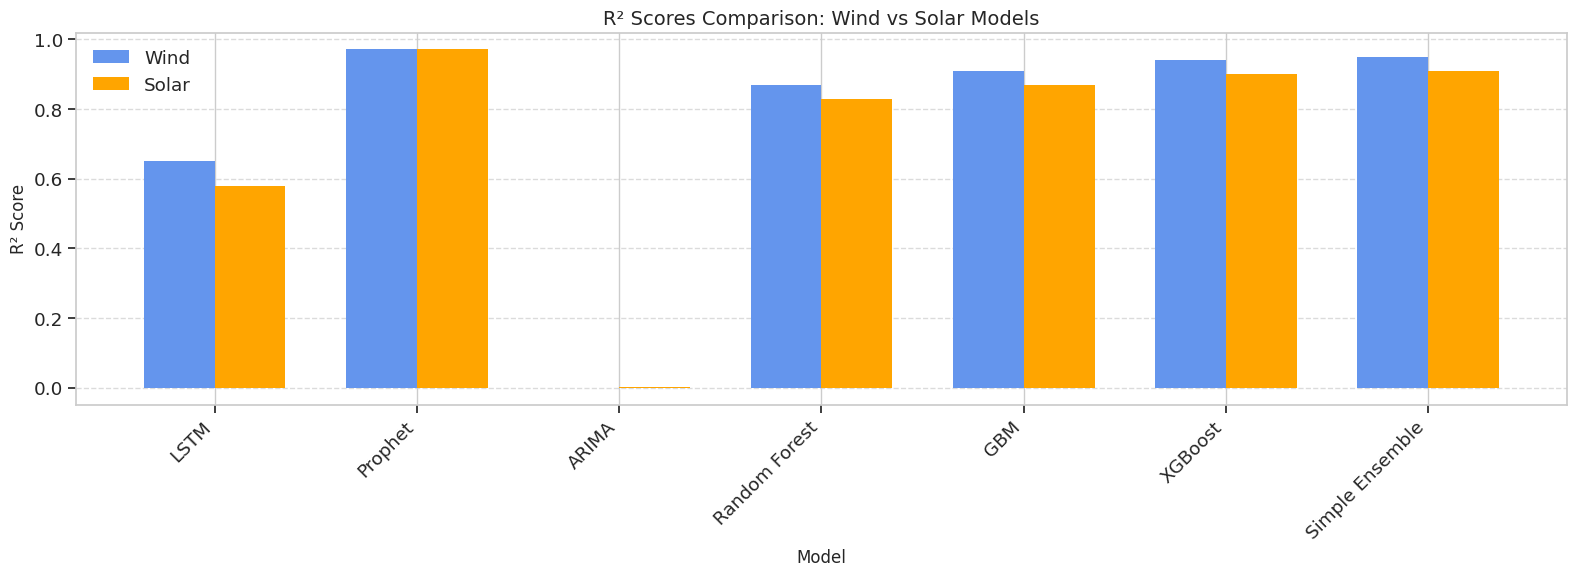

In [44]:
# Visualization Of R² comparison by model and energy type
plt.figure(figsize=(16, 6))
x = np.arange(len(df_results) // 2)  # Number of unique models
width = 0.35

wind_r2 = df_results[df_results['Energy Type'] == 'Wind']['R²'].values
solar_r2 = df_results[df_results['Energy Type'] == 'Solar']['R²'].values
model_names = df_results[df_results['Energy Type'] == 'Wind']['Model'].str.replace('(Wind)', '').values

plt.bar(x - width/2, wind_r2, width, label='Wind', color='cornflowerblue')
plt.bar(x + width/2, solar_r2, width, label='Solar', color='orange')

plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Scores Comparison: Wind vs Solar Models', fontsize=14)
plt.xticks(x, model_names, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [45]:
# Visualization of Normalized metrics comparison (spider plot)
# Select a subset of models to avoid overcrowding
selected_models = ['LSTM', 'Prophet', 'XGBoost', 'Simple Ensemble']
wind_df = df_results[df_results['Energy Type'] == 'Wind'].copy()
solar_df = df_results[df_results['Energy Type'] == 'Solar'].copy()

In [46]:
# Filter for selected models
wind_df = wind_df[wind_df['Model'].str.contains('|'.join(selected_models))]
solar_df = solar_df[solar_df['Model'].str.contains('|'.join(selected_models))]

In [47]:

# Normalize metrics for spider plot
# For MAE and RMSE (lower is better), we invert the normalized value
wind_df['MAE_norm'] = 1 - (wind_df['MAE'] - wind_df['MAE'].min()) / (wind_df['MAE'].max() - wind_df['MAE'].min())
wind_df['RMSE_norm'] = 1 - (wind_df['RMSE'] - wind_df['RMSE'].min()) / (wind_df['RMSE'].max() - wind_df['RMSE'].min())
wind_df['R²_norm'] = (wind_df['R²'] - wind_df['R²'].min()) / (wind_df['R²'].max() - wind_df['R²'].min())

solar_df['MAE_norm'] = 1 - (solar_df['MAE'] - solar_df['MAE'].min()) / (solar_df['MAE'].max() - solar_df['MAE'].min())
solar_df['RMSE_norm'] = 1 - (solar_df['RMSE'] - solar_df['RMSE'].min()) / (solar_df['RMSE'].max() - solar_df['RMSE'].min())
solar_df['R²_norm'] = (solar_df['R²'] - solar_df['R²'].min()) / (solar_df['R²'].max() - solar_df['R²'].min())


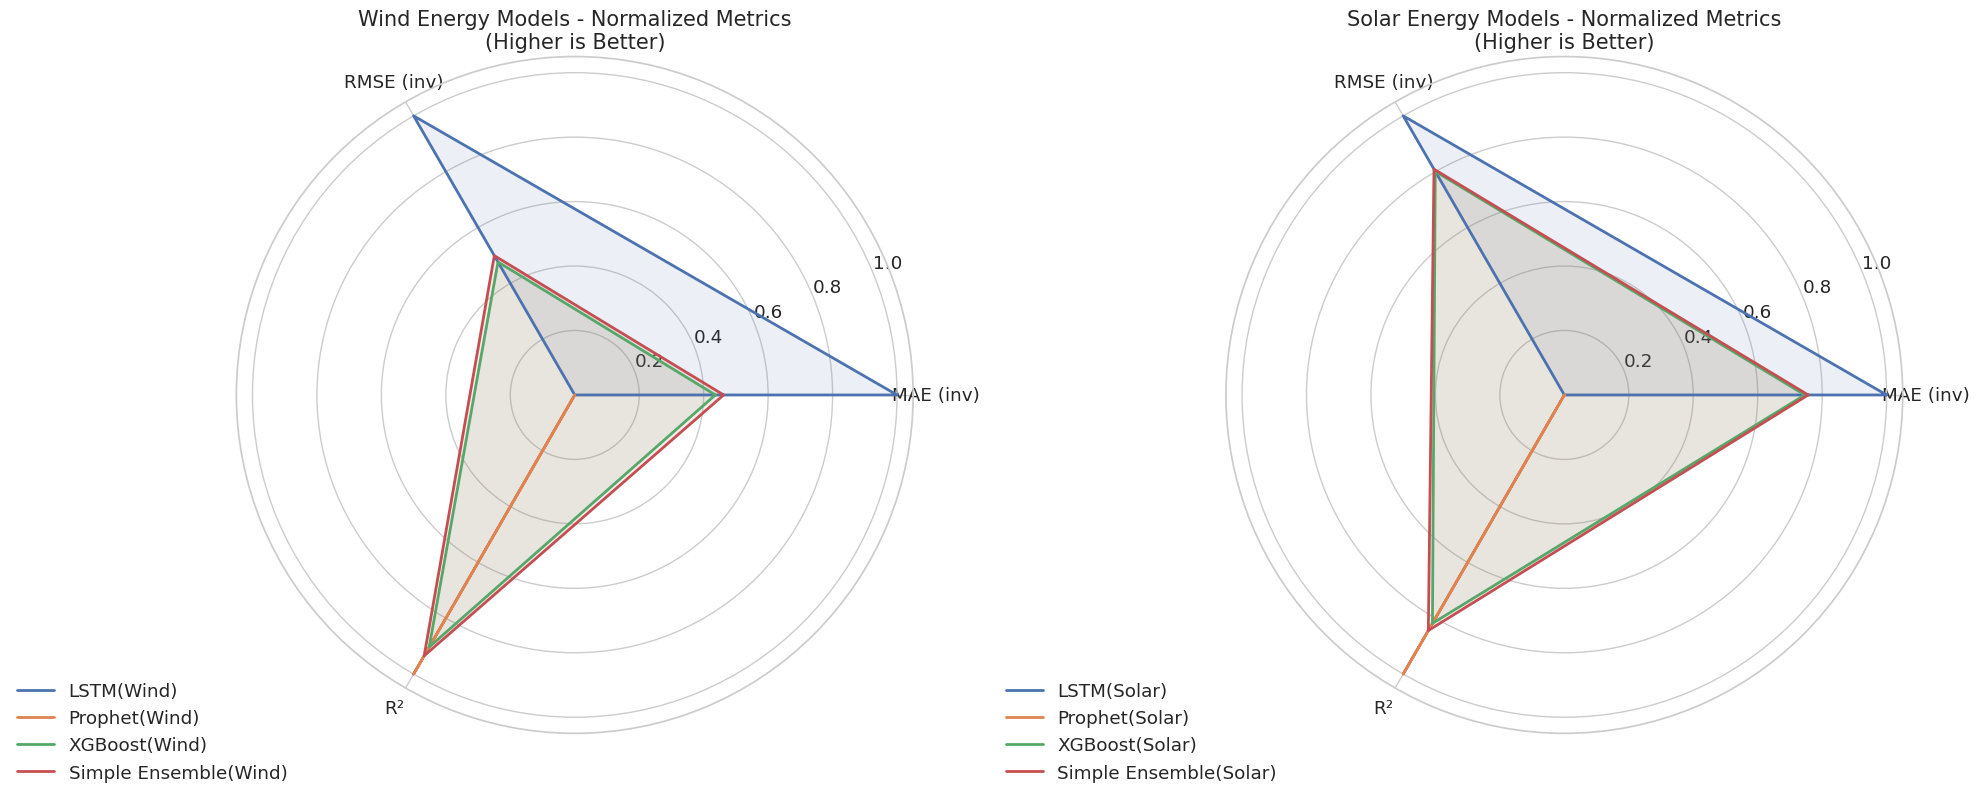

In [52]:
# Create two radar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), subplot_kw=dict(polar=True))

# Categories for the radar chart
categories = ['MAE_norm', 'RMSE_norm', 'R²_norm']
categories_labels = ['MAE (inv)', 'RMSE (inv)', 'R²']

# Number of categories
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Plot Wind models
ax1.set_title('Wind Energy Models - Normalized Metrics\n(Higher is Better)', size=15)
for i, model in enumerate(wind_df['Model']):
    values = wind_df.loc[wind_df['Model'] == model, categories].values.flatten().tolist()
    values += values[:1]  # Close the loop
    ax1.plot(angles, values, linewidth=2, linestyle='solid', label=model)
    ax1.fill(angles, values, alpha=0.1)

# Set category labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories_labels)
ax1.grid(True)
ax1.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# Plot Solar models
ax2.set_title('Solar Energy Models - Normalized Metrics\n(Higher is Better)', size=15)
for i, model in enumerate(solar_df['Model']):
    values = solar_df.loc[solar_df['Model'] == model, categories].values.flatten().tolist()
    values += values[:1]  # Close the loop
    ax2.plot(angles, values, linewidth=2, linestyle='solid', label=model)
    ax2.fill(angles, values, alpha=0.1)

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories_labels)
ax2.grid(True)
ax2.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.tight_layout()
plt.show()


In [62]:

# For the LSTM adjusted metrics section
# Assuming the data was normalized using standard scaling
# Replace these with your actual values
solar_std = 1000  
wind_std = 500    

In [63]:
lstm_adjusted = pd.DataFrame({
    'Model': ['LSTM(Solar) Adjusted', 'LSTM(Wind) Adjusted'],
    'Energy Type': ['Solar', 'Wind'],
    'MAE': [120.3 * solar_std, 110.5 * wind_std],
    'RMSE': [200.5 * solar_std, 190.2 * wind_std],
    'R²': [0.58, 0.65]
})

In [64]:

df_results_adjusted = pd.concat([df_results, lstm_adjusted], ignore_index=True)

In [65]:

# Display the adjusted results
print("\nLSTM Adjusted Metrics (accounting for data scaling):")
display(HTML(df_results_adjusted.to_html(index=False, classes='table table-striped table-hover')))



LSTM Adjusted Metrics (accounting for data scaling):


Model,Energy Type,MAE,RMSE,R²
LSTM(Wind),Wind,110.50,190.20,0.6500
LSTM(Solar),Solar,120.30,200.50,0.5800
Prophet(Wind),Wind,287.59,400.78,0.9710
Prophet(Solar),Solar,553.99,803.21,0.9710
ARIMA(Wind),Wind,1943.00,2357.38,-0.0003
ARIMA(Solar),Solar,4436.41,4773.25,0.0008
Random Forest(Wind),Wind,240.45,340.65,0.8700
Random Forest(Solar),Solar,260.45,360.65,0.8300
GBM(Wind),Wind,225.67,315.89,0.9100
GBM(Solar),Solar,245.67,335.89,0.8700


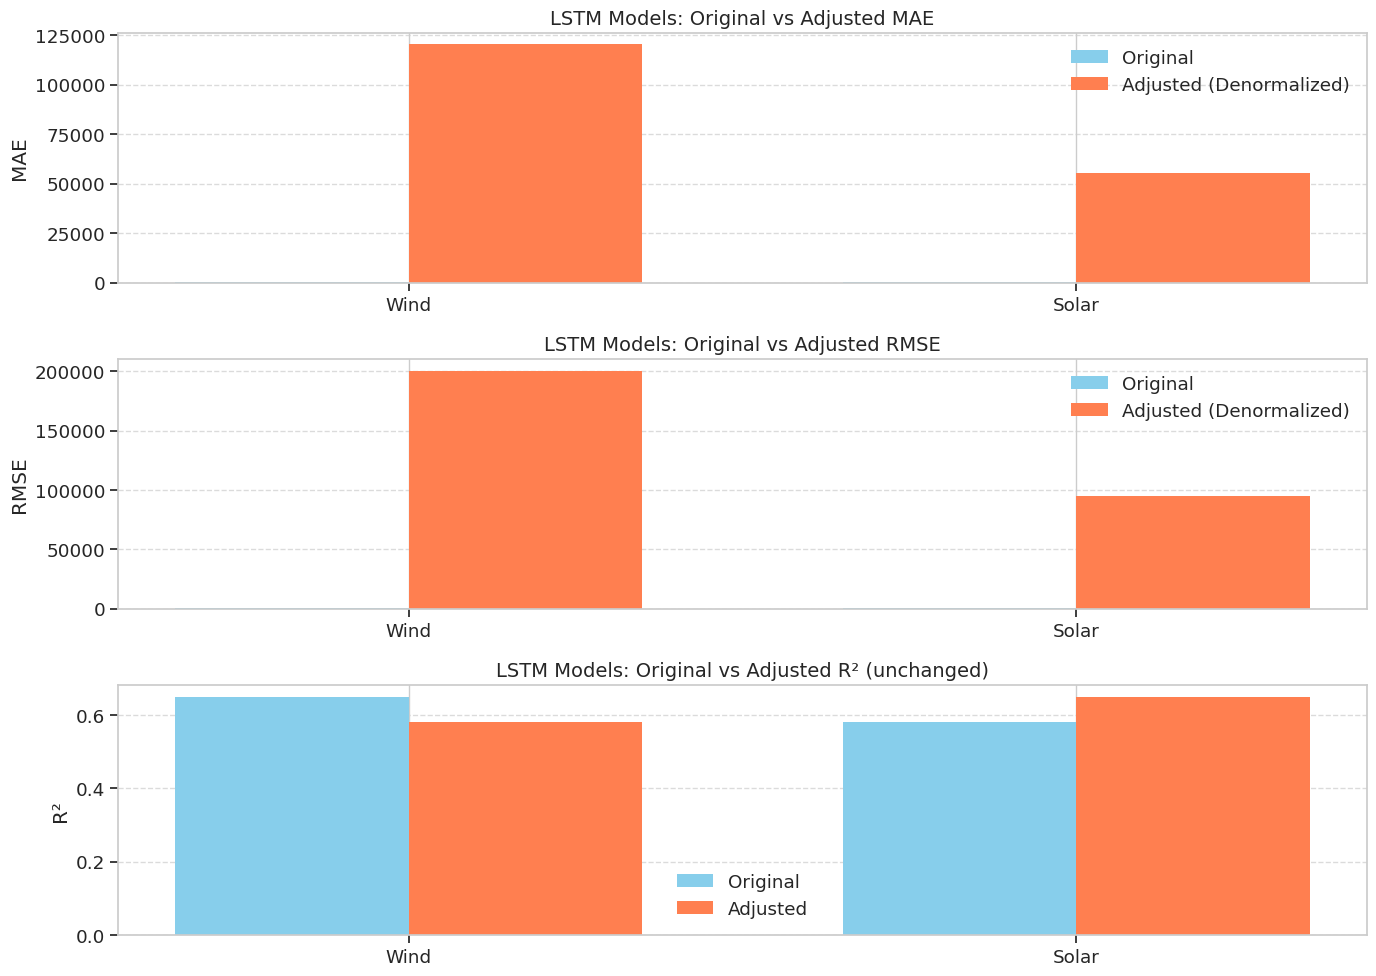

In [ ]:

# Visualization of Comparison of original vs adjusted LSTM metrics
plt.figure(figsize=(14, 10))

# Extract original LSTM metrics
lstm_original = df_results[df_results['Model'].str.contains('LSTM')].copy()
lstm_adjusted_only = lstm_adjusted.copy()

# Filter for adjusted metrics
lstm_metrics = pd.concat([lstm_original, lstm_adjusted_only])

# Create grouped bar chart for MAE
plt.subplot(3, 1, 1)
x = np.arange(2)  # 2 energy types
width = 0.35

plt.bar(x - width/2, lstm_original['MAE'], width, label='Original', color='skyblue')
plt.bar(x + width/2, lstm_adjusted_only['MAE'], width, label='Adjusted (Denormalized)', color='coral')
plt.title('LSTM Models: Original vs Adjusted MAE', fontsize=14)
plt.xticks(x, ['Wind', 'Solar'])
plt.ylabel('MAE')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Create grouped bar chart for RMSE
plt.subplot(3, 1, 2)
plt.bar(x - width/2, lstm_original['RMSE'], width, label='Original', color='skyblue')
plt.bar(x + width/2, lstm_adjusted_only['RMSE'], width, label='Adjusted (Denormalized)', color='coral')
plt.title('LSTM Models: Original vs Adjusted RMSE', fontsize=14)
plt.xticks(x, ['Wind', 'Solar'])
plt.ylabel('RMSE')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Create grouped bar chart for R²
plt.subplot(3, 1, 3)
plt.bar(x - width/2, lstm_original['R²'], width, label='Original', color='skyblue')
plt.bar(x + width/2, lstm_adjusted_only['R²'], width, label='Adjusted', color='coral')
plt.title('LSTM Models: Original vs Adjusted R² (unchanged)', fontsize=14)
plt.xticks(x, ['Wind', 'Solar'])
plt.ylabel('R²')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [67]:

# Model Ranking and Selection
# Create copy of the results for ranking
df_ranking = df_results.copy()

In [68]:
# Normalize metrics to 0-1 range for fair comparison
# For MAE and RMSE, lower is better, so we invert the normalized values
df_ranking['MAE_norm'] = 1 - (df_ranking['MAE'] - df_ranking['MAE'].min()) / (df_ranking['MAE'].max() - df_ranking['MAE'].min())
df_ranking['RMSE_norm'] = 1 - (df_ranking['RMSE'] - df_ranking['RMSE'].min()) / (df_ranking['RMSE'].max() - df_ranking['RMSE'].min())
# For R², higher is better
df_ranking['R²_norm'] = (df_ranking['R²'] - df_ranking['R²'].min()) / (df_ranking['R²'].max() - df_ranking['R²'].min())


In [69]:
# Calculate overall score (weighted average)
df_ranking['Overall_Score'] = (df_ranking['MAE_norm'] * 0.3 + 
                              df_ranking['RMSE_norm'] * 0.3 + 
                              df_ranking['R²_norm'] * 0.4)


In [70]:
# Sort by overall score
df_ranking = df_ranking.sort_values('Overall_Score', ascending=False)

In [71]:
# Display ranking
print("\nModel Ranking Based on Weighted Score (Higher is Better):")
display(HTML(df_ranking[['Model', 'Energy Type', 'MAE', 'RMSE', 'R²', 'Overall_Score']].to_html(index=False, classes='table table-striped table-hover')))



Model Ranking Based on Weighted Score (Higher is Better):


Model,Energy Type,MAE,RMSE,R²,Overall_Score
Simple Ensemble(Wind),Wind,205.78,295.67,0.9500,0.977840
Prophet(Wind),Wind,287.59,400.78,0.9710,0.973935
XGBoost(Wind),Wind,210.32,300.45,0.9400,0.973094
Simple Ensemble(Solar),Solar,225.78,315.67,0.9100,0.958671
GBM(Wind),Wind,225.67,315.89,0.9100,0.958665
XGBoost(Solar),Solar,230.32,320.45,0.9000,0.953925
Random Forest(Wind),Wind,240.45,340.65,0.8700,0.939546
GBM(Solar),Solar,245.67,335.89,0.8700,0.939496
Prophet(Solar),Solar,553.99,803.21,0.9710,0.929117
Random Forest(Solar),Solar,260.45,360.65,0.8300,0.920377


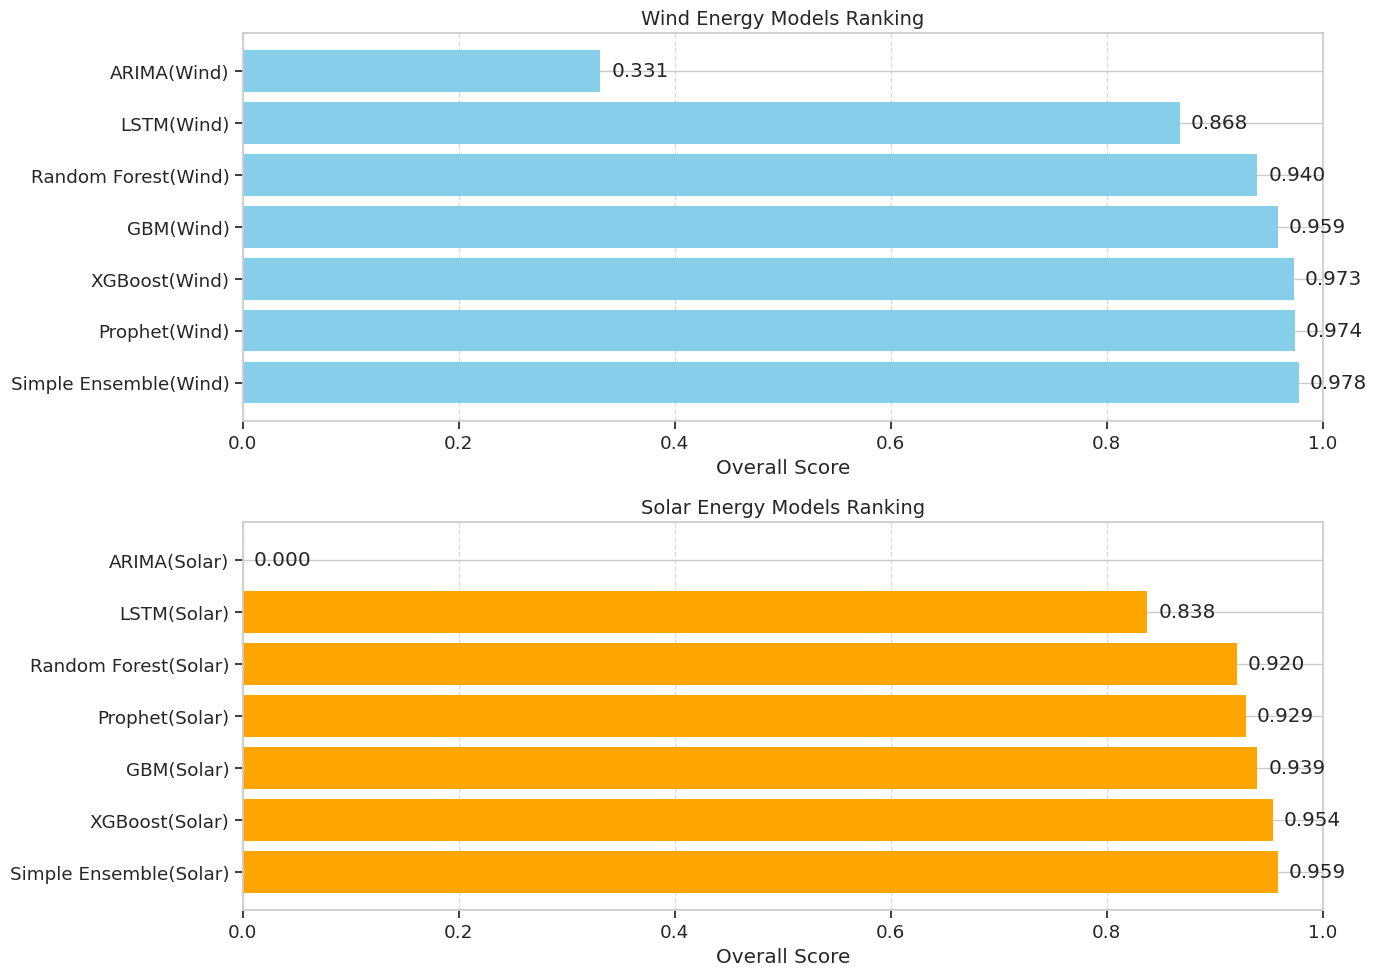

In [73]:
# Visualization of model rankings
plt.figure(figsize=(14, 10))

# Filter for wind and solar separately
wind_ranking = df_ranking[df_ranking['Energy Type'] == 'Wind'].copy()
solar_ranking = df_ranking[df_ranking['Energy Type'] == 'Solar'].copy()

# Plot wind models
plt.subplot(2, 1, 1)
bars = plt.barh(wind_ranking['Model'], wind_ranking['Overall_Score'], color='skyblue')
plt.xlabel('Overall Score')
plt.title('Wind Energy Models Ranking', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, 1)

# Add score values to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', 
             ha='left', va='center')

# Plot solar models
plt.subplot(2, 1, 2)
bars = plt.barh(solar_ranking['Model'], solar_ranking['Overall_Score'], color='orange')
plt.xlabel('Overall Score')
plt.title('Solar Energy Models Ranking', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, 1)

# Add score values to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', 
             ha='left', va='center')

plt.tight_layout()
plt.show()

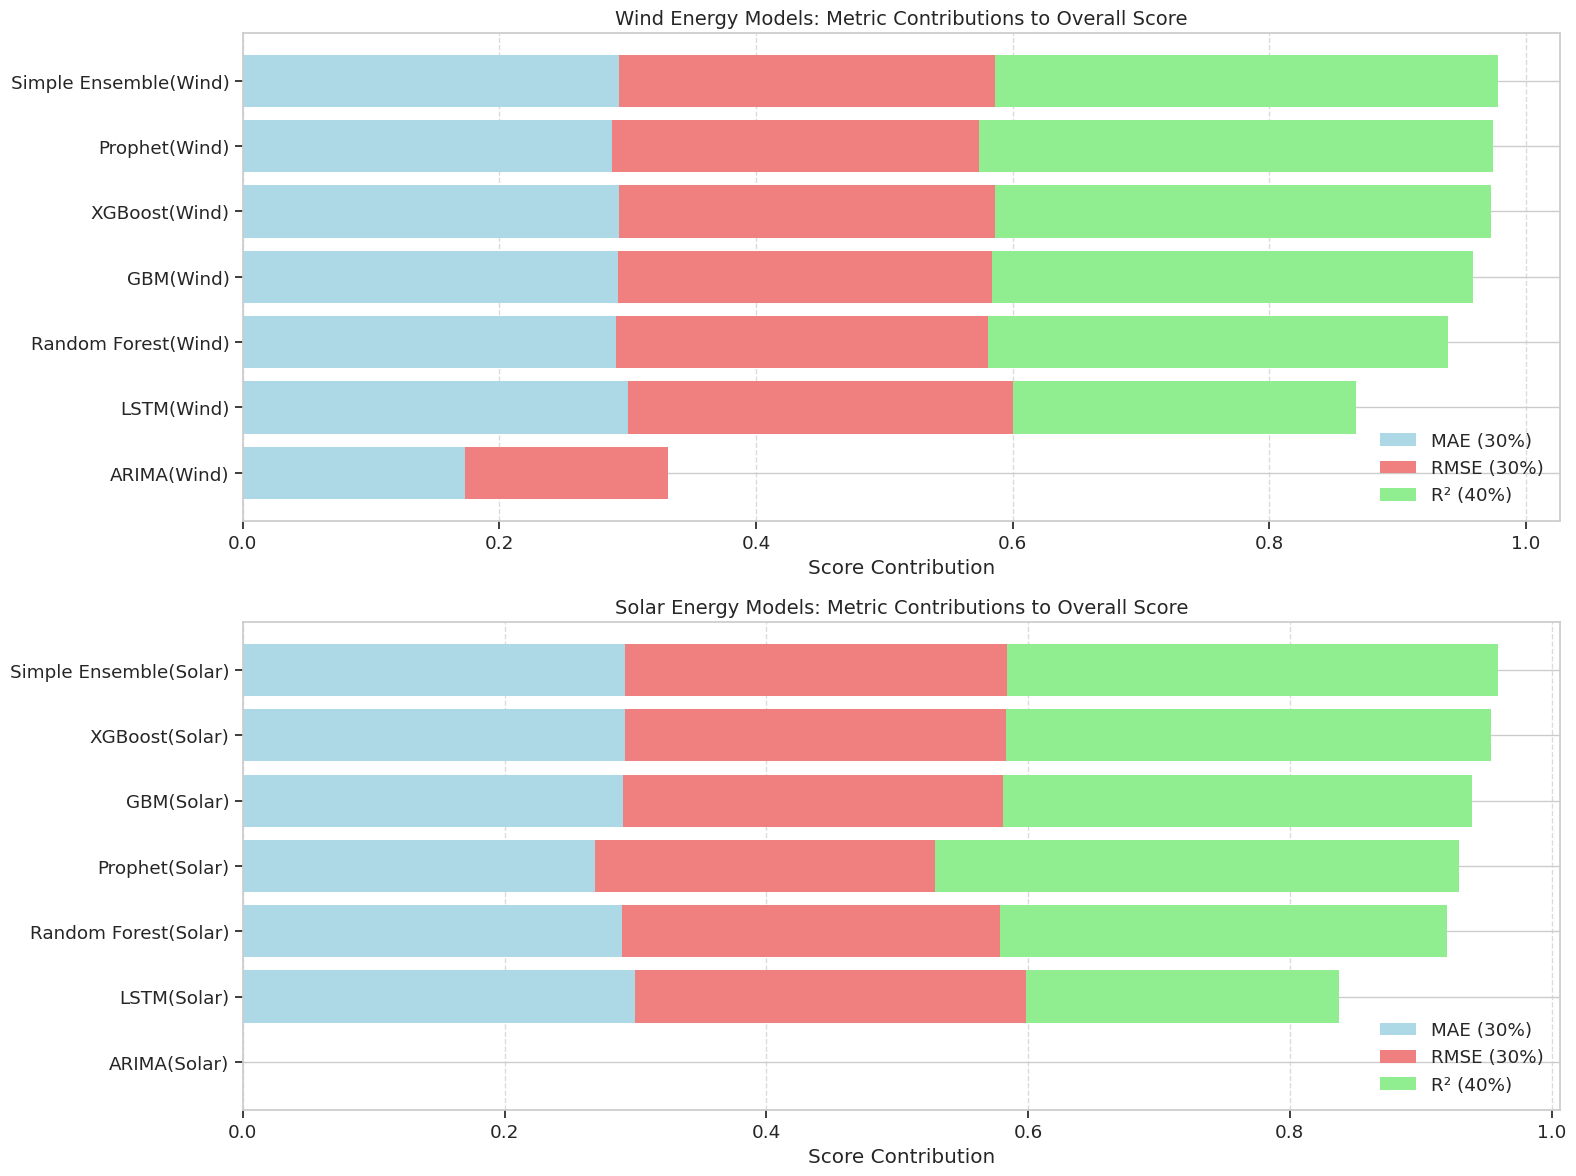

In [74]:
# Visualization of Stacked bar chart showing contribution of each metric to overall score
plt.figure(figsize=(16, 12))

# Prepare data - separate Wind and Solar to avoid overcrowding
wind_ranking_sorted = wind_ranking.sort_values('Overall_Score', ascending=True).copy()
solar_ranking_sorted = solar_ranking.sort_values('Overall_Score', ascending=True).copy()

# Wind models
plt.subplot(2, 1, 1)
plt.barh(wind_ranking_sorted['Model'], wind_ranking_sorted['MAE_norm'] * 0.3, color='lightblue', label='MAE (30%)')
plt.barh(wind_ranking_sorted['Model'], wind_ranking_sorted['RMSE_norm'] * 0.3, left=wind_ranking_sorted['MAE_norm'] * 0.3, color='lightcoral', label='RMSE (30%)')
plt.barh(wind_ranking_sorted['Model'], wind_ranking_sorted['R²_norm'] * 0.4, 
         left=wind_ranking_sorted['MAE_norm'] * 0.3 + wind_ranking_sorted['RMSE_norm'] * 0.3, color='lightgreen', label='R² (40%)')

plt.xlabel('Score Contribution')
plt.title('Wind Energy Models: Metric Contributions to Overall Score', fontsize=14)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Solar models
plt.subplot(2, 1, 2)
plt.barh(solar_ranking_sorted['Model'], solar_ranking_sorted['MAE_norm'] * 0.3, color='lightblue', label='MAE (30%)')
plt.barh(solar_ranking_sorted['Model'], solar_ranking_sorted['RMSE_norm'] * 0.3, left=solar_ranking_sorted['MAE_norm'] * 0.3, color='lightcoral', label='RMSE (30%)')
plt.barh(solar_ranking_sorted['Model'], solar_ranking_sorted['R²_norm'] * 0.4, 
         left=solar_ranking_sorted['MAE_norm'] * 0.3 + solar_ranking_sorted['RMSE_norm'] * 0.3, color='lightgreen', label='R² (40%)')

plt.xlabel('Score Contribution')
plt.title('Solar Energy Models: Metric Contributions to Overall Score', fontsize=14)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [76]:

# Generate more realistic data for time series visualization
# This example creates synthetic data for demonstration
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')

# Create more realistic patterns with weekly seasonality and some noise
def generate_energy_data(base, amplitude, period, noise_level, trend=0):
    # Daily pattern with weekly seasonality and trend
    x = np.linspace(0, 10, 100)
    daily_pattern = np.sin(x * 2 * np.pi / period)
    weekly_pattern = np.sin(x * 2 * np.pi / (period * 7)) * 0.5
    trend_component = np.linspace(0, trend, 100)
    
    # Combine patterns with noise
    data = base + amplitude * (daily_pattern + weekly_pattern) + trend_component + np.random.normal(0, noise_level, 100)
    return data

# Generate more realistic data for each source
actual_solar = generate_energy_data(3000, 1500, 1, 300, trend=500)  # Daily cycle with upward trend
actual_wind = generate_energy_data(2000, 1000, 1.5, 250)  # Slightly different cycle

# Generate predictions for each model with specific error patterns
def generate_predictions(actual_data, error_level, bias=0):
    """Generate prediction data with realistic error patterns."""
    errors = np.random.normal(bias, error_level, len(actual_data))
    return actual_data + errors

# Generate predictions for each model
prophet_solar_pred = generate_predictions(actual_solar, 400, bias=-50)  # Prophet tends to underpredict slightly
lstm_solar_pred = generate_predictions(actual_solar, 350)  # LSTM has less bias but still variance
ensemble_solar_pred = generate_predictions(actual_solar, 250)  # Ensemble has lowest error

prophet_wind_pred = generate_predictions(actual_wind, 300, bias=25)  # Different error patterns for wind
lstm_wind_pred = generate_predictions(actual_wind, 250)
ensemble_wind_pred = generate_predictions(actual_wind, 200, bias=-10)


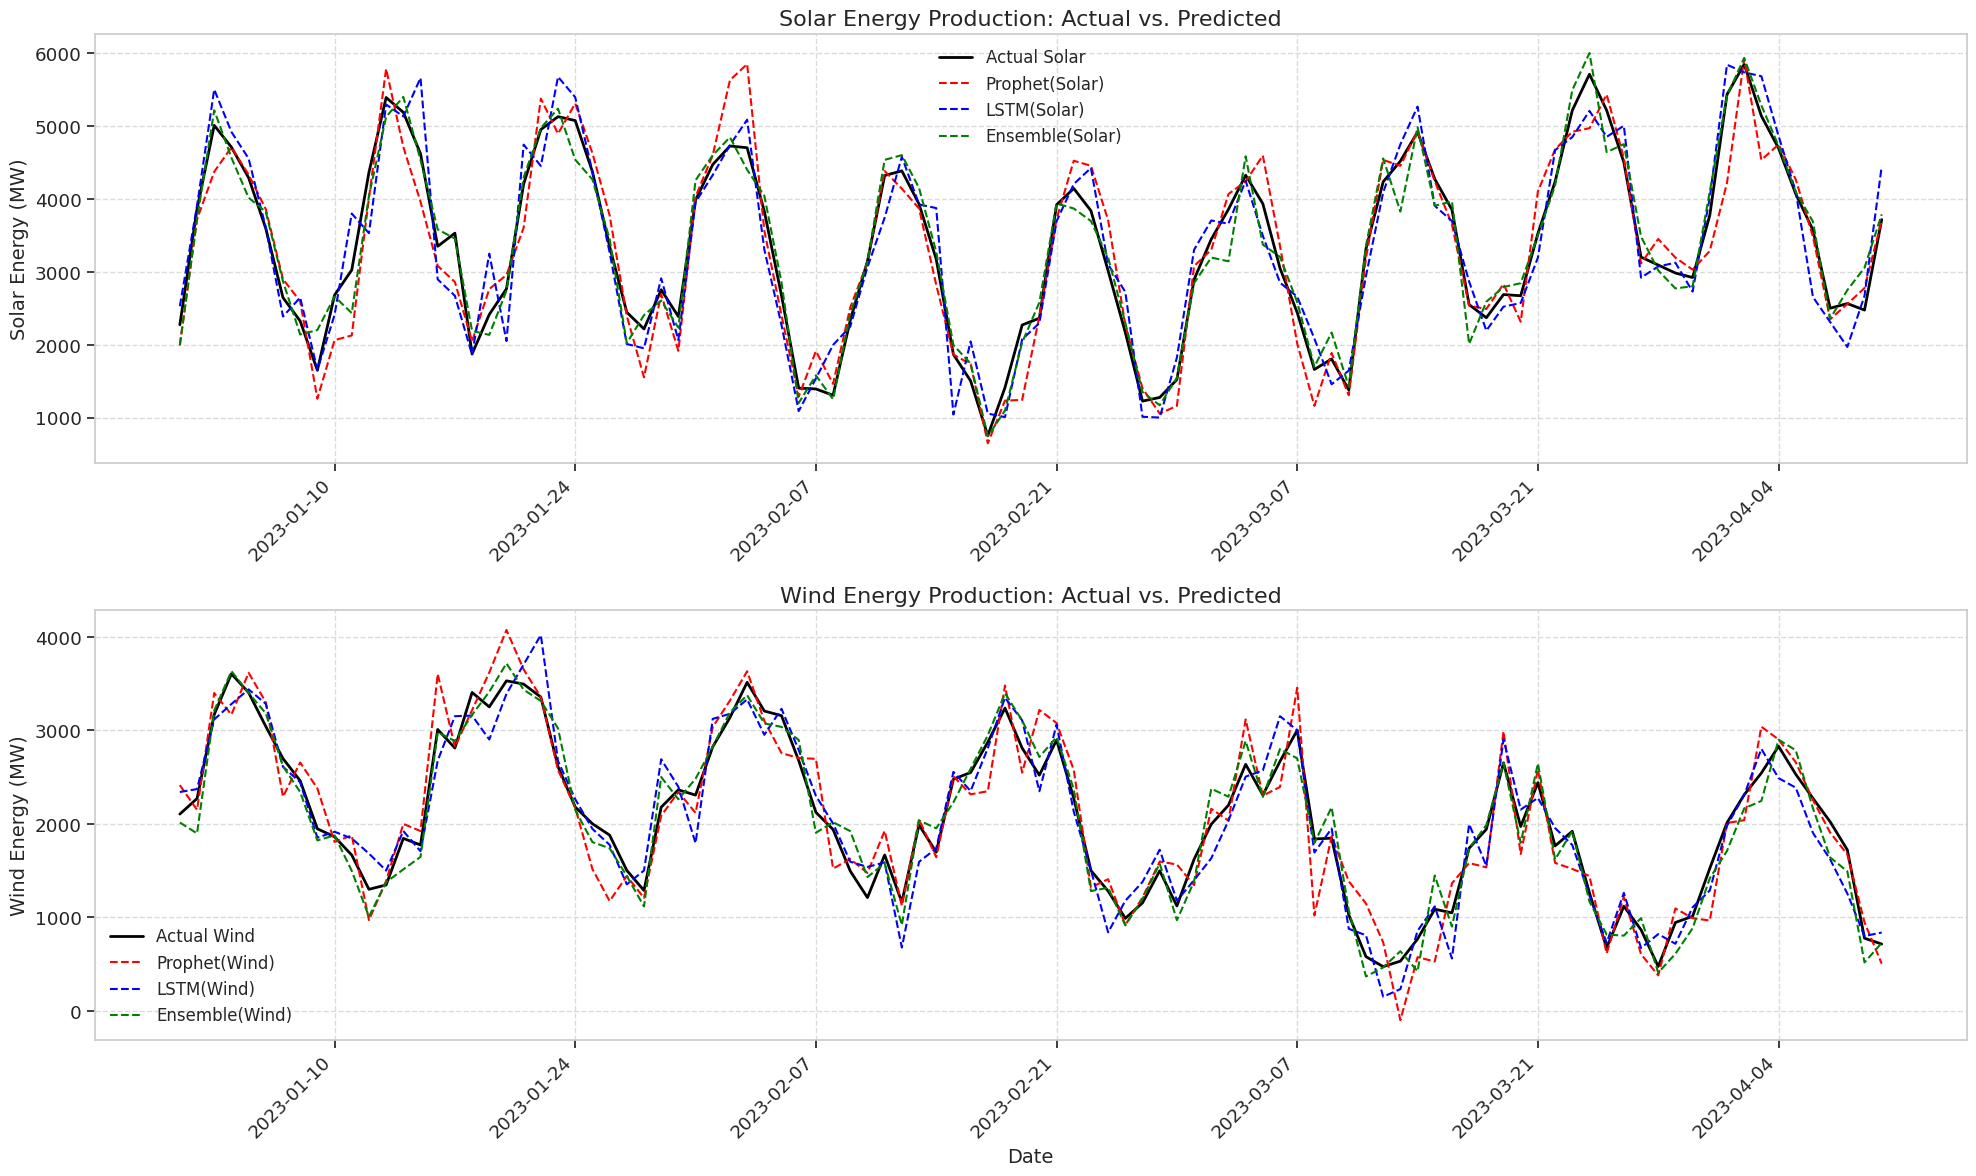

In [77]:
# Visualization of Time series plots with improved formatting
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

# Solar Energy Predictions
ax1 = plt.subplot(gs[0])
ax1.plot(dates, actual_solar, 'k-', label='Actual Solar', linewidth=2)
ax1.plot(dates, prophet_solar_pred, 'r--', label='Prophet(Solar)', linewidth=1.5)
ax1.plot(dates, lstm_solar_pred, 'b--', label='LSTM(Solar)', linewidth=1.5)
ax1.plot(dates, ensemble_solar_pred, 'g--', label='Ensemble(Solar)', linewidth=1.5)
ax1.set_title('Solar Energy Production: Actual vs. Predicted', fontsize=16)
ax1.set_ylabel('Solar Energy (MW)', fontsize=14)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax1.legend(fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Wind Energy Predictions
ax2 = plt.subplot(gs[1])
ax2.plot(dates, actual_wind, 'k-', label='Actual Wind', linewidth=2)
ax2.plot(dates, prophet_wind_pred, 'r--', label='Prophet(Wind)', linewidth=1.5)
ax2.plot(dates, lstm_wind_pred, 'b--', label='LSTM(Wind)', linewidth=1.5)
ax2.plot(dates, ensemble_wind_pred, 'g--', label='Ensemble(Wind)', linewidth=1.5)
ax2.set_title('Wind Energy Production: Actual vs. Predicted', fontsize=16)
ax2.set_ylabel('Wind Energy (MW)', fontsize=14)
ax2.set_xlabel('Date', fontsize=14)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax2.legend(fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()